In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.5 MB/s eta 0:00:00


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Cell 1: Install Library (update)
!pip install transformers[torch] accelerate datasets pandas numpy scikit-learn BERTopic
!pip install sastrawi nltk imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.7 MB/s eta 0:00:00


# [Objektif 1] Analisis Sentimen dengan IndoBERT

> Add blockquote



In [ ]:
# Cell 1: Import Semua Library yang Dibutuhkan

import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Scikit-Learn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hugging Face Transformers & Datasets
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


--- Memuat dan Membersihkan Data (Dataset Baru) ---
Jumlah data awal: 18988
Jumlah data setelah filter OOT: 14909
Jumlah data final setelah cleaning & hapus duplikat: 14679

Pembersihan data selesai. Contoh perbedaan hasil cleaning:
                                        cleaned_bert  \
0  apalagi indonesia memiliki kekayaan nikel yang...   
1  pemerintah indonesia nampaknya tidak mainmain ...   
2  dunia semakin tua energi terbarukan adalah mas...   
3  sih elon teh hebat nya hyg kak luar angkasa ny...   
4  penjualan mobil listrik diprediksi meroket di ...   

                                          cleaned_ml  
0  indonesia milik kaya nikel nikel salah materia...  
1  perintah indonesia nampaknya mainmain kembang ...  
2  dunia tua energi baru depanselamat tinggal ene...  
3  elon teh hebat hyg kak angkasa nyieun spacex h...  
4                  jual mobil listrik prediksi roket  

--- Word Cloud dari Data Bersih (cleaned_bert) ---


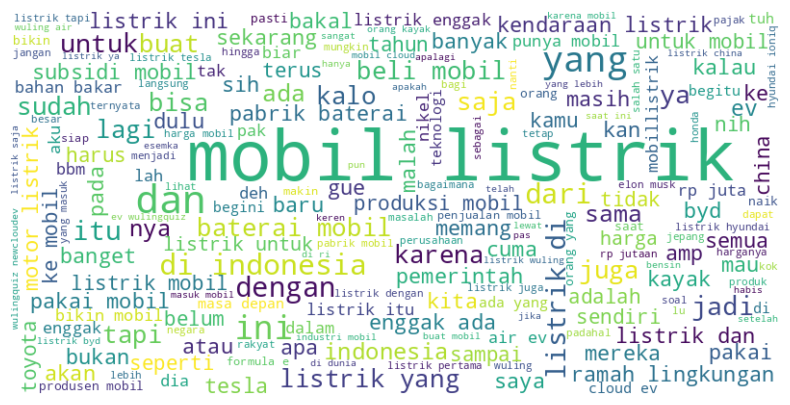

In [ ]:
# Cell 2: Memuat, Membersihkan Data, dan Membuat Word Cloud (update FINAL)

import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Download NLTK Stopwords
nltk.download('stopwords')

# 2. Setup Kamus Eksternal dan Stemmer
kamus_alay_url = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"
kamus_alay = pd.read_csv(kamus_alay_url)
slang_dict = dict(zip(kamus_alay['slang'], kamus_alay['formal']))

factory = StemmerFactory()
stemmer = factory.create_stemmer()

list_stopwords = stopwords.words('indonesian')
list_stopwords.extend(["yg", "dg", "rt", "dgn", "ny", "d", "k", "k", "kyk", "nya", "nih", "sih", "si", "tau", "tdk", "tuh", "utk", "ya", "jd", "jgn", "sdh", "aja", "n", "t", "wkwk", "wkwkwk", "hahaha", "haha", "ga", "gak", "tak", "jg", "gn", "sm"])

# 3. Muat Dataset BARU
print("--- Memuat dan Membersihkan Data (Dataset Baru) ---")
df = pd.read_csv('dataset x.csv')
print(f"Jumlah data awal: {len(df)}")

# 4. [update] Terapkan "Master Filter" untuk Hapus Data OOT (Iklan, dll)
# Daftar kata kunci/frasa yang WAJIB ada (huruf kecil semua)
master_keywords = [
    'mobil listrik', 'subsidi mobil listrik', 'insentif mobil listrik',
    'kona', 'binguo', 'byd', 'ev', 'ioniq', 'omoda', 'spklu'
]
# Buat satu pattern regex besar ( | = ATAU )
# case=False berarti tidak peduli huruf besar/kecil
filter_pattern = '|'.join(master_keywords)

# Pastikan 'full_text' adalah string sebelum difilter
df['full_text'] = df['full_text'].astype(str)
# Simpan hanya baris yang mengandung salah satu keyword di atas
df_filtered = df[df['full_text'].str.contains(filter_pattern, case=False)].copy()
print(f"Jumlah data setelah filter OOT: {len(df_filtered)}")

# 5. Buat Fungsi Cleaning (diterapkan pada data yang sudah difilter)
def clean_text_bert(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)

    words = text.split()
    normalized_words = [slang_dict.get(word, word) for word in words]
    text = ' '.join(normalized_words)

    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_text_ml(text):
    text = clean_text_bert(text)
    words = text.split()
    words = [word for word in words if word not in list_stopwords]
    text = ' '.join(words)
    text = stemmer.stem(text)
    return text

# 6. Terapkan Cleaning dan Hapus Duplikat
df_filtered.drop_duplicates(subset='full_text', inplace=True)
df_filtered['cleaned_bert'] = df_filtered['full_text'].apply(clean_text_bert)
df_filtered['cleaned_ml'] = df_filtered['full_text'].apply(clean_text_ml)

df = df_filtered[(df_filtered['cleaned_bert'] != '') & (df_filtered['cleaned_ml'] != '')].reset_index(drop=True)
print(f"Jumlah data final setelah cleaning & hapus duplikat: {len(df)}")

# 7. Tampilkan data setelah cleaning
print("\nPembersihan data selesai. Contoh perbedaan hasil cleaning:")
print(df[['cleaned_bert', 'cleaned_ml']].head())

# 8. Visualisasi Word Cloud (dari data BERT)
print("\n--- Word Cloud dari Data Bersih (cleaned_bert) ---")
all_text = ' '.join(df['cleaned_bert'])
if all_text:
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

In [ ]:
# Cell 3: Pelabelan Sentimen (update - Menambahkan Contoh Hasil Labeling)

print("\n--- Memulai Pelabelan Data Otomatis (Lexicon InSet) ---")

# 1. Unduh Lexicon InSet
pos_lex_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
neg_lex_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"
df_pos = pd.read_csv(pos_lex_url, sep='\t', header=None, names=['word', 'weight'])
df_neg = pd.read_csv(neg_lex_url, sep='\t', header=None, names=['word', 'weight'])

# Gabungkan dan konversi kolom 'weight' menjadi angka (integer)
df_lexicon = pd.concat([df_pos, df_neg])
df_lexicon['weight'] = pd.to_numeric(df_lexicon['weight'], errors='coerce')
df_lexicon = df_lexicon.dropna(subset=['weight'])
df_lexicon['weight'] = df_lexicon['weight'].astype(int)

# 2. Buat kamus lexicon
lexicon_dict = df_lexicon.set_index('word')['weight'].to_dict()

# 3. Fungsi pelabelan sederhana
def label_sentiment_inset(text):
    score = 0
    words = text.split()
    for word in words:
        score += lexicon_dict.get(word, 0)

    if score > 0:
        return 'positif'
    elif score < 0:
        return 'negatif'
    else:
        return 'netral'

# 4. Terapkan pelabelan ke data 'cleaned_bert'
df['sentiment'] = df['cleaned_bert'].apply(label_sentiment_inset)
print("Pelabelan data selesai. Berikut distribusinya:")
print(df['sentiment'].value_counts())

# 5. [PENAMBAHAN] Tampilkan contoh hasil pelabelan untuk Sanity Check
print("\n--- Contoh Hasil Pelabelan InSet (Sanity Check) ---")
# Menampilkan 10 baris acak dari kolom teks bersih dan hasil sentimennya
# Mengatur display agar teks tidak terpotong
pd.set_option('display.max_colwidth', 200)
print(df[['cleaned_bert', 'sentiment']].sample(10, random_state=42))
# Mengembalikan display ke default jika perlu
# pd.reset_option('display.max_colwidth')


--- Memulai Pelabelan Data Otomatis (Lexicon InSet) ---
Pelabelan data selesai. Berikut distribusinya:
sentiment
negatif    10256
positif     3867
netral       556
Name: count, dtype: int64

--- Contoh Hasil Pelabelan InSet (Sanity Check) ---
                                                                                                                                      cleaned_bert  \
7403                                    luhut binsar beri bocoran ada produsen mobil listrik bakal investasi rp triliun di indonesia pikiranrakyat   
8382   menteri keuangan as janet yellen mengeluhkan perusahaanperusahaan tiongkok memproduksi terlalu banyak baterai panel surya dan mobil listrik   
5763                                                               subsidi bbm dan krl dikurangin terus dipindah ke pembelian mobil listrikmenarik   
2937                                                                                                          ini tampang mobil listrik baru bmw i   
1624  

In [ ]:
# Cell 3.5: [OPSIONAL] Simpan Progres Cleaning & Labeling
print("Menyimpan hasil data cleaning dan labeling ke file...")
df.to_csv('data_cleaned_labeled.csv', index=False)
print("Selesai! File 'data_cleaned_labeled.csv' telah disimpan.")

Menyimpan hasil data cleaning dan labeling ke file...
Selesai! File 'data_cleaned_labeled.csv' telah disimpan.


In [ ]:
# Cell 3.6: [OPSIONAL] Muat Progres Cleaning & Labeling
print("Memuat data yang sudah bersih dan terlabel...")
df = pd.read_csv('data_cleaned_labeled.csv')

# Perlu definisikan ulang map ini untuk cell-cell berikutnya
labels_map = {'positif': 2, 'netral': 1, 'negatif': 0}
print("Data berhasil dimuat. Distribusi sentimen:")
print(df['sentiment'].value_counts())
print("\nAnda bisa langsung lanjut ke Cell 4 (Training IndoBERT).")

Memuat data yang sudah bersih dan terlabel...
Data berhasil dimuat. Distribusi sentimen:
sentiment
negatif    10256
positif     3867
netral       556
Name: count, dtype: int64

Anda bisa langsung lanjut ke Cell 4 (Training IndoBERT).



--- Mempersiapkan Pelatihan IndoBERT dengan 3-Fold Cross Validation ---
Membuat kolom 'label' dari 'sentiment'...
Menghitung Class Weights...
Class Weights berhasil dihitung: tensor([0.4771, 8.8004, 1.2653], device='cuda:0')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/9786 [00:00<?, ? examples/s]

Map:   0%|          | 0/4893 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision,Recall
1,0.914800,0.798000,0.768853,0.780682,0.552750,0.810900,0.768853
2,0.763100,0.777980,0.821991,0.824066,0.592520,0.834441,0.821991
3,0.508300,0.934007,0.831596,0.842839,0.620705,0.855945,0.831596
4,0.366300,1.308468,0.845902,0.850082,0.630049,0.857029,0.845902
5,0.199300,1.599804,0.855303,0.853400,0.632384,0.852245,0.855303


Hasil Evaluasi Fold 3: {'eval_loss': 1.5998039245605469, 'eval_accuracy': 0.8553034947884733, 'eval_f1_weighted': 0.8533999595907846, 'eval_f1_macro': 0.6323840232980458, 'eval_precision': 0.8522449954466917, 'eval_recall': 0.8553034947884733, 'eval_runtime': 64.8552, 'eval_samples_per_second': 75.445, 'eval_steps_per_second': 4.718, 'epoch': 5.0}

## [OBJEKTIF 1] ANALISIS SENTIMEN DENGAN INDOBERT ##
--- Evaluasi Akhir (Rata-rata dari 3-Fold Cross Validation) ---
{'eval_accuracy': np.float64(0.8560528646365557), 'eval_f1_weighted': np.float64(0.854885662549031), 'eval_f1_macro': np.float64(0.6324958478062742), 'eval_precision': np.float64(0.8541791720190416), 'eval_recall': np.float64(0.8560528646365557)}

--- Confusion Matrix Gabungan (Hasil K-Fold IndoBERT) ---


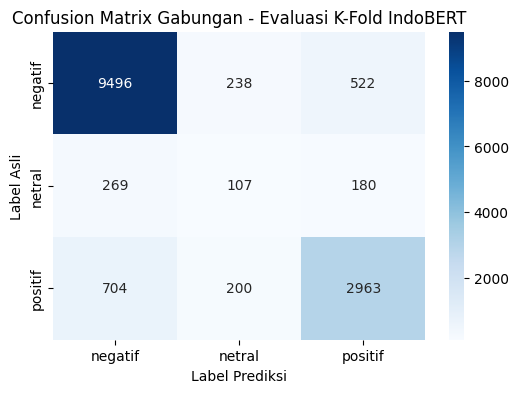

In [ ]:
# Cell 4: Pelatihan Model IndoBERT (update - Tambah Confusion Matrix K-Fold)

from sklearn.utils.class_weight import compute_class_weight
import torch
from datasets import Dataset
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification, EarlyStoppingCallback
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Mempersiapkan Pelatihan IndoBERT dengan 3-Fold Cross Validation ---")
labels_map = {'positif': 2, 'netral': 1, 'negatif': 0}
labels_map_inv = {v: k for k, v in labels_map.items()} # Untuk label plot
class_labels = [labels_map_inv[i] for i in range(len(labels_map))]

if 'label' not in df.columns or df['label'].isnull().any():
    print("Membuat kolom 'label' dari 'sentiment'...")
    df['label'] = df['sentiment'].map(labels_map)
    df = df.dropna(subset=['label'])
    df['label'] = df['label'].astype(int)

print("Menghitung Class Weights...")
unique_labels = np.unique(df['label'])
class_weights = compute_class_weight(class_weight='balanced', classes=unique_labels, y=df['label'])
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to("cuda" if torch.cuda.is_available() else "cpu")

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels", None)
        current_device = next(model.parameters()).device
        weights_tensor_device = weights_tensor.to(current_device)
        outputs = model(**{k: v for k, v in inputs.items() if k != 'labels'})
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights_tensor_device)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

print(f"Class Weights berhasil dihitung: {weights_tensor}")

n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def tokenize_function(examples):
    return tokenizer(examples["cleaned_bert"], padding="max_length", truncation=True, max_length=256)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'precision': precision_score(labels, preds, average='weighted', zero_division=0),
        'recall': recall_score(labels, preds, average='weighted')
    }

all_fold_metrics = []
all_fold_true_labels = [] # [update] Untuk kumpulkan label asli
all_fold_preds = []       # [update] Untuk kumpulkan prediksi

training_args = TrainingArguments(
    output_dir=f"./results/static_run",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
)

for fold, (train_idx, val_idx) in enumerate(skf.split(df['cleaned_bert'], df['label'])):
    print(f"\n===== MEMULAI FOLD {fold+1}/{n_splits} =====")

    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]
    train_dataset = Dataset.from_pandas(train_df).map(tokenize_function, batched=True)
    val_dataset = Dataset.from_pandas(val_df).map(tokenize_function, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p1", num_labels=3)

    trainer = CustomTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.args.output_dir = f"./results/fold_{fold+1}"
    trainer.train()
    eval_results = trainer.evaluate()
    all_fold_metrics.append(eval_results)

    # [update] Dapatkan prediksi dari fold ini dan simpan
    predictions = trainer.predict(val_dataset)
    all_fold_true_labels.extend(predictions.label_ids)
    all_fold_preds.extend(predictions.predictions.argmax(-1))

    print(f"Hasil Evaluasi Fold {fold+1}: {eval_results}")

print("\n## [OBJEKTIF 1] ANALISIS SENTIMEN DENGAN INDOBERT ##")
print(f"--- Evaluasi Akhir (Rata-rata dari {n_splits}-Fold Cross Validation) ---")
avg_metrics = {
    'eval_accuracy': np.mean([res['eval_accuracy'] for res in all_fold_metrics]),
    'eval_f1_weighted': np.mean([res['eval_f1_weighted'] for res in all_fold_metrics]),
    'eval_f1_macro': np.mean([res['eval_f1_macro'] for res in all_fold_metrics]),
    'eval_precision': np.mean([res['eval_precision'] for res in all_fold_metrics]),
    'eval_recall': np.mean([res['eval_recall'] for res in all_fold_metrics])
}
print(avg_metrics)
indoBERT_metrics = avg_metrics

# [update] Tampilkan Confusion Matrix Gabungan dari K-Fold
print("\n--- Confusion Matrix Gabungan (Hasil K-Fold IndoBERT) ---")
cm_kfold = confusion_matrix(all_fold_true_labels, all_fold_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_kfold, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix Gabungan - Evaluasi K-Fold IndoBERT')
plt.ylabel('Label Asli')
plt.xlabel('Label Prediksi')
plt.show()

# [Objektif 2] Evaluasi Kinerja IndoBERT vs. SVM, LR, & RF

## [OBJEKTIF 2] EVALUASI KINERJA INDOBERT VS. SVM, LR, & RF ##

===== VALIDASI FOLD 1/3 UNTUK MODEL ML KLASIK =====
Menerapkan SMOTE pada data training...
Melatih dan mengevaluasi SVM...
Melatih dan mengevaluasi Logistic Regression...
Melatih dan mengevaluasi Random Forest...

===== VALIDASI FOLD 2/3 UNTUK MODEL ML KLASIK =====
Menerapkan SMOTE pada data training...
Melatih dan mengevaluasi SVM...
Melatih dan mengevaluasi Logistic Regression...
Melatih dan mengevaluasi Random Forest...

===== VALIDASI FOLD 3/3 UNTUK MODEL ML KLASIK =====
Menerapkan SMOTE pada data training...
Melatih dan mengevaluasi SVM...
Melatih dan mengevaluasi Logistic Regression...
Melatih dan mengevaluasi Random Forest...

--- Laporan Klasifikasi Lengkap untuk SVM ---
              precision    recall  f1-score   support

     negatif       0.80      0.94      0.86     10256
      netral       0.33      0.09      0.14       556
     positif       0.72      0.46      0.56      3867

    accuracy                  

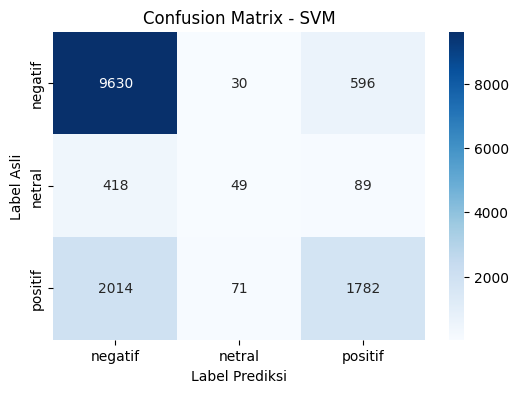


--- Laporan Klasifikasi Lengkap untuk Logistic Regression ---
              precision    recall  f1-score   support

     negatif       0.86      0.77      0.81     10256
      netral       0.08      0.19      0.12       556
     positif       0.57      0.62      0.59      3867

    accuracy                           0.71     14679
   macro avg       0.50      0.53      0.51     14679
weighted avg       0.75      0.71      0.73     14679



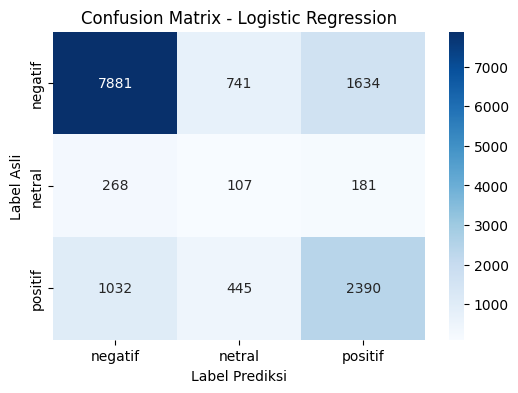


--- Laporan Klasifikasi Lengkap untuk Random Forest ---
              precision    recall  f1-score   support

     negatif       0.81      0.87      0.84     10256
      netral       0.34      0.08      0.14       556
     positif       0.60      0.54      0.57      3867

    accuracy                           0.76     14679
   macro avg       0.58      0.50      0.51     14679
weighted avg       0.74      0.76      0.74     14679



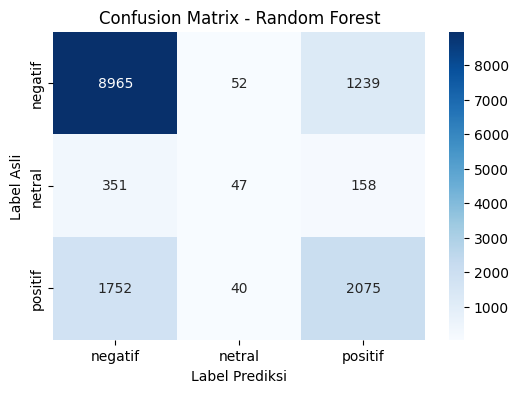


--- Tabel Perbandingan Kinerja Seluruh Model (Evaluasi K-Fold) ---
                     Accuracy  F1-Weighted  F1-Macro  Precision  Recall
IndoBERT               0.8561       0.8549    0.6325     0.8542  0.8561
SVM                    0.7808       0.7564    0.5215     0.7605  0.7808
Logistic Regression    0.7070       0.7270    0.5063     0.7526  0.7070
Random Forest          0.7553       0.7416    0.5139     0.7362  0.7553


In [ ]:
# Cell 5: [Objektif 2] Evaluasi Kinerja (update - Tampilkan Report Lengkap)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
import seaborn as sns

print("## [OBJEKTIF 2] EVALUASI KINERJA INDOBERT VS. SVM, LR, & RF ##")

all_true_labels = []
all_preds = {name: [] for name in ["SVM", "Logistic Regression", "Random Forest"]}

# Pastikan n_splits=3 sesuai dengan Cell 4
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(skf.split(df['cleaned_ml'], df['label'])):
    print(f"\n===== VALIDASI FOLD {fold+1}/{n_splits} UNTUK MODEL ML KLASIK =====")

    train_df, val_df = df.iloc[train_idx], df.iloc[val_idx]

    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_tfidf = vectorizer.fit_transform(train_df['cleaned_ml'])
    X_val_tfidf = vectorizer.transform(val_df['cleaned_ml'])
    y_train, y_val = train_df['label'], val_df['label']

    all_true_labels.extend(y_val)

    print("Menerapkan SMOTE pada data training...")
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_tfidf, y_train)

    for name in all_preds.keys():
        print(f"Melatih dan mengevaluasi {name}...")
        model = {"SVM": SVC(), "Logistic Regression": LogisticRegression(max_iter=1000), "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)}[name]
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val_tfidf)
        all_preds[name].extend(y_pred)

final_ml_metrics = {}
for name, y_pred_total in all_preds.items():

    # [update] Tampilkan Classification Report Lengkap (termasuk Class Precision/Recall)
    print(f"\n--- Laporan Klasifikasi Lengkap untuk {name} ---")
    print(classification_report(all_true_labels, y_pred_total, target_names=class_labels, zero_division=0))

    report = classification_report(all_true_labels, y_pred_total, output_dict=True, zero_division=0)
    final_ml_metrics[name] = {
        'Accuracy': report['accuracy'],
        'F1-Weighted': report['weighted avg']['f1-score'],
        'F1-Macro': report['macro avg']['f1-score'],
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall']
    }

    # Tampilkan Confusion Matrix
    cm = confusion_matrix(all_true_labels, y_pred_total)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Label Asli')
    plt.xlabel('Label Prediksi')
    plt.show()

# Gabungkan dengan hasil IndoBERT
all_final_metrics = {
    "IndoBERT": {
        "Accuracy": indoBERT_metrics.get('eval_accuracy', 0),
        "F1-Weighted": indoBERT_metrics.get('eval_f1_weighted', 0),
        "F1-Macro": indoBERT_metrics.get('eval_f1_macro', 0),
        "Precision": indoBERT_metrics.get('eval_precision', 0),
        "Recall": indoBERT_metrics.get('eval_recall', 0)
    },
    "SVM": final_ml_metrics['SVM'],
    "Logistic Regression": final_ml_metrics['Logistic Regression'],
    "Random Forest": final_ml_metrics['Random Forest']
}

comparison_df = pd.DataFrame(all_final_metrics).T
print("\n--- Tabel Perbandingan Kinerja Seluruh Model (Evaluasi K-Fold) ---")
print(comparison_df.round(4))

In [ ]:
# Cell 5.5: [update] Prediksi Final (Fix OSError & Tambah Confusion Matrix)

import numpy as np
import json
import os
from transformers import BertForSequenceClassification, BertTokenizer, Trainer
from datasets import Dataset
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("## [OBJEKTIF 1] HASIL AKHIR ANALISIS SENTIMEN INDOBERT ##")
print("--- Memuat Model IndoBERT Terbaik dari Hasil K-Fold ---")

# 1. Cari tahu fold mana yang punya F1 terbaik
all_f1_scores = [res['eval_f1_weighted'] for res in all_fold_metrics]
best_fold_index = np.argmax(all_f1_scores)
best_fold_path = f"./results/fold_{best_fold_index + 1}"

print(f"Model terbaik ditemukan di Fold {best_fold_index + 1} (F1-Weighted: {all_f1_scores[best_fold_index]:.4f})")

# 2. Cari folder checkpoint terbaik di dalam folder fold
try:
    subfolders = [f.path for f in os.scandir(best_fold_path) if f.is_dir() and 'checkpoint' in f.name]
    step_numbers = [int(f.split('-')[-1]) for f in subfolders]
    best_checkpoint_step = max(step_numbers)
    best_checkpoint_path = f"{best_fold_path}/checkpoint-{best_checkpoint_step}"
    print(f"Menemukan checkpoint terbaik di: {best_checkpoint_path}")
except Exception:
    print(f"ERROR: Tidak dapat menemukan folder 'checkpoint-...' di dalam {best_fold_path}.")
    best_checkpoint_path = best_fold_path

# 3. Muat model dan tokenizer
print(f"Memuat MODEL dari: {best_checkpoint_path}")
best_model = BertForSequenceClassification.from_pretrained(best_checkpoint_path)
print("Memuat TOKENIZER dari: indobenchmark/indobert-base-p1")
best_tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

# 4. Buat Trainer baru hanya untuk prediksi
prediction_trainer = Trainer(model=best_model)

# 5. Siapkan keseluruhan data untuk diprediksi
full_dataset = Dataset.from_pandas(df)
def tokenize_for_predict(examples):
    return best_tokenizer(examples["cleaned_bert"], padding="max_length", truncation=True, max_length=256)

tokenized_full_dataset = full_dataset.map(tokenize_for_predict, batched=True)

# 6. Lakukan prediksi
print("\n--- Memprediksi Sentimen Seluruh Dataset Menggunakan IndoBERT ---")
raw_predictions = prediction_trainer.predict(tokenized_full_dataset)
predicted_labels = raw_predictions.predictions.argmax(-1)

# 7. Buat kolom hasil prediksi baru
df['indoBERT_prediction'] = [labels_map_inv.get(label, 'netral') for label in predicted_labels]


--- Hasil Final Sentimen Masyarakat (Berdasarkan Prediksi IndoBERT) ---
indoBERT_prediction
negatif    10272
positif     3843
netral       564
Name: count, dtype: int64

--- Confusion Matrix Final (Prediksi IndoBERT vs. Label InSet) ---


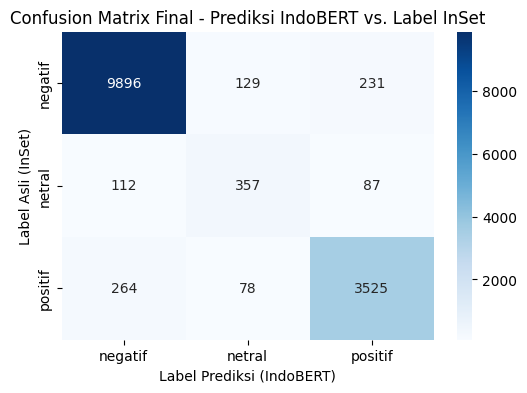

In [ ]:
# 8. Tampilkan hasil akhir Objektif 1
print("\n--- Hasil Final Sentimen Masyarakat (Berdasarkan Prediksi IndoBERT) ---")
print(df['indoBERT_prediction'].value_counts())

# 9. [update] Tampilkan Confusion Matrix Final (Prediksi vs. Ground Truth InSet)
print("\n--- Confusion Matrix Final (Prediksi IndoBERT vs. Label InSet) ---")
cm_final = confusion_matrix(df['sentiment'], df['indoBERT_prediction'], labels=class_labels)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix Final - Prediksi IndoBERT vs. Label InSet')
plt.ylabel('Label Asli (InSet)')
plt.xlabel('Label Prediksi (IndoBERT)')
plt.show()

In [ ]:
# Cell 5.6: [OPSIONAL] Simpan Progres FINAL (Setelah Prediksi IndoBERT)

print("Menyimpan hasil data final (termasuk prediksi IndoBERT)...")
# Kita simpan dataframe 'df' yang sekarang sudah punya semua kolom
df.to_csv('data_final_with_predictions.csv', index=False)
print("Selesai! File 'data_final_with_predictions.csv' telah disimpan.")
print("Jika Colab restart, jalankan Cell 1 (Install) lalu Cell 5.7 (Muat Progres) ini.")

Menyimpan hasil data final (termasuk prediksi IndoBERT)...
Selesai! File 'data_final_with_predictions.csv' telah disimpan.
Jika Colab restart, jalankan Cell 1 (Install) lalu Cell 5.7 (Muat Progres) ini.


In [ ]:
# Cell 5.7: [OPSIONAL] Muat Progres FINAL (Langsung Lanjut ke BERTopic)

import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords

print("Memuat data final yang sudah berisi prediksi IndoBERT...")
df = pd.read_csv('data_final_with_predictions.csv')

# Kita harus definisikan ulang beberapa variabel penting untuk Cell 6 & 7
print("Mendefinisikan ulang variabel yang dibutuhkan...")

# 1. Definisikan ulang list_stopwords (dari Cell 2)
nltk.download('stopwords')
list_stopwords = stopwords.words('indonesian')
list_stopwords.extend(["yg", "dg", "rt", "dgn", "ny", "d", "k", "k", "kyk", "nya", "nih", "sih", "si", "tau", "tdk", "tuh", "utk", "ya", "jd", "jgn", "sdh", "aja", "n", "t", "wkwk", "wkwkwk", "hahaha", "haha", "ga", "gak", "tak", "jg", "gn", "sm"])

# 2. Definisikan ulang labels_map (dari Cell 4)
labels_map = {'positif': 2, 'netral': 1, 'negatif': 0}

print("Data berhasil dimuat.")
print("Distribusi Sentimen Awal (InSet):")
print(df['sentiment'].value_counts())
print("\nDistribusi Sentimen Akhir (IndoBERT):")
print(df['indoBERT_prediction'].value_counts())

print("\nAnda bisa langsung lanjut ke Cell 6 (Analisis BERTopic).")

Memuat data final yang sudah berisi prediksi IndoBERT...
Mendefinisikan ulang variabel yang dibutuhkan...
Data berhasil dimuat.
Distribusi Sentimen Awal (InSet):
sentiment
negatif    10256
positif     3867
netral       556
Name: count, dtype: int64

Distribusi Sentimen Akhir (IndoBERT):
indoBERT_prediction
negatif    10272
positif     3843
netral       564
Name: count, dtype: int64

Anda bisa langsung lanjut ke Cell 6 (Analisis BERTopic).


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# [Objektif 3] Analisis Topik Penyebab Sentimen Negatif

In [ ]:
# Cell 6: [Objektif 3] Analisis Topik, Evaluasi, dan Visualisasi Bar Chart (update INPUT)

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
import pandas as pd

print("## [OBJEKTIF 3] ANALISIS TOPIK PENYEBAB SENTIMEN NEGATIF ##")
print("--- Memulai analisis topik pada sentimen negatif (Hasil Prediksi IndoBERT) ---")

# [update] Ambil data negatif berdasarkan hasil prediksi IndoBERT
negative_tweets = df[df['indoBERT_prediction'] == 'negatif']['cleaned_bert'].tolist()

if len(negative_tweets) > 15:
    # [update] Gunakan 'list_stopwords' yang reliabel dari Cell 2
    vectorizer_model = CountVectorizer(stop_words=list_stopwords)

    topic_model = BERTopic(
        embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        vectorizer_model=vectorizer_model,
        verbose=False,
        language="multilingual",
        min_topic_size=5
    )
    topics, probs = topic_model.fit_transform(negative_tweets)

    print("\n--- Topik Dominan pada Sentimen Negatif ---")
    topic_info = topic_model.get_topic_info()
    print(topic_info)

    # Menghitung Topic Coherence & Diversity Score
    try:
        documents = pd.DataFrame({"Document": negative_tweets, "Topic": topics})
        documents = documents[documents.Topic != -1]
        tokenized_docs = [doc.split() for doc in documents.Document]

        bertopic_topics = [[word for word, _ in topic_model.get_topic(topic_num)]
                           for topic_num in documents.Topic.unique()]

        dictionary = Dictionary(tokenized_docs)
        corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

        coherence_model = CoherenceModel(topics=bertopic_topics, texts=tokenized_docs, corpus=corpus, dictionary=dictionary, coherence='c_v')
        coherence = coherence_model.get_coherence()
        print(f"\nTopic Coherence Score (C_V): {coherence:.4f}")

        all_topic_words = [word for topic in bertopic_topics for word in topic]
        unique_words = set(all_topic_words)
        diversity = len(unique_words) / len(all_topic_words) if all_topic_words else 0
        print(f"Topic Diversity Score: {diversity:.4f}")
    except Exception as e:
        print(f"\nTidak dapat menghitung Coherence/Diversity: {e}")

    # Visualisasi Bar Chart
    valid_topics = topic_info[topic_info.Topic != -1]
    if not valid_topics.empty:
        print("\n--- Visualisasi Bar Chart per Topik ---")
        fig_bar = topic_model.visualize_barchart(top_n_topics=8)
        fig_bar.show()
    else:
        print("\nTidak ada topik signifikan untuk divisualisasikan.")
else:
    print("\nJumlah tweet negatif (berdasarkan prediksi IndoBERT) tidak cukup untuk analisis topik.")

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


## [OBJEKTIF 3] ANALISIS TOPIK PENYEBAB SENTIMEN NEGATIF ##
--- Memulai analisis topik pada sentimen negatif (Hasil Prediksi IndoBERT) ---


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


--- Topik Dominan pada Sentimen Negatif ---
     Topic  Count                                   Name  \
0       -1   4270             -1_kalo_listrik_mobil_beli   
1        0    311                 0_china_cina_jepang_as   
2        1    281   1_baterai_battery_garansi_baterainya   
3        2    153      2_presiden_menteri_jokowi_jahanam   
4        3    144     3_indonesia_hadir_terlaris_seagull   
..     ...    ...                                    ...   
281    280      5         280_crypto_jarian_xch_fenomena   
282    281      5          281_ago_look_successful_heres   
283    282      5             282_war_uang_emas_gubernur   
284    283      5  283_terdengar_remehkan_merek_refleksi   
285    284      5        284_golok_jaka_menjilat_sembung   

                                        Representation  \
0    [kalo, listrik, mobil, beli, kayak, pakai, ken...   
1    [china, cina, jepang, as, impor, produk, pasar...   
2    [baterai, battery, garansi, baterainya, merawa...   
3 

In [ ]:
# Cell 7: Visualisasi Bar Chart (Terpisah)

# Cek apakah variabel dari Cell 6 sudah ada
if 'topic_model' in locals() and 'topic_info' in locals():
    valid_topics = topic_info[topic_info.Topic != -1]
    if not valid_topics.empty:
        print("\n--- Visualisasi Bar Chart per Topik ---")
        try:
            # Panggil fungsi visualisasi Bar Chart
            fig_bar = topic_model.visualize_barchart(top_n_topics=8)
            # .show() penting untuk menampilkannya di Colab
            fig_bar.show()
        except Exception as e:
            print(f"Tidak dapat menampilkan bar chart: {e}")
    else:
        print("\nTidak ada topik signifikan untuk divisualisasikan.")
else:
    print("ERROR: Harap jalankan Cell 6 terlebih dahulu untuk membuat 'topic_model' dan 'topic_info'.")


--- Visualisasi Bar Chart per Topik ---



--- Word Cloud untuk Topik-Topik Negatif ---


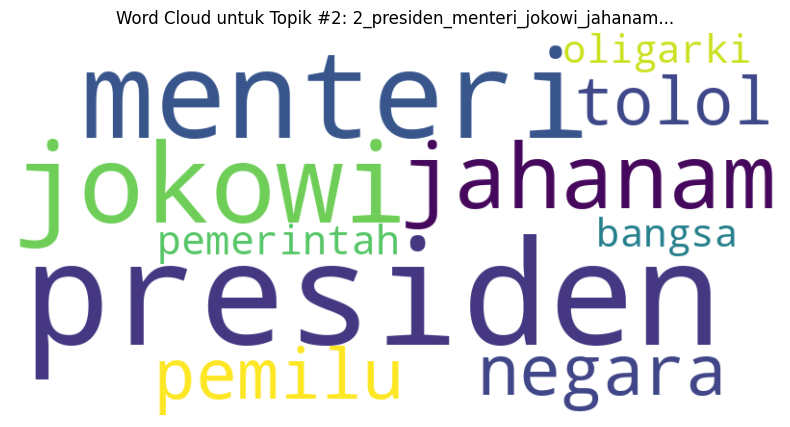

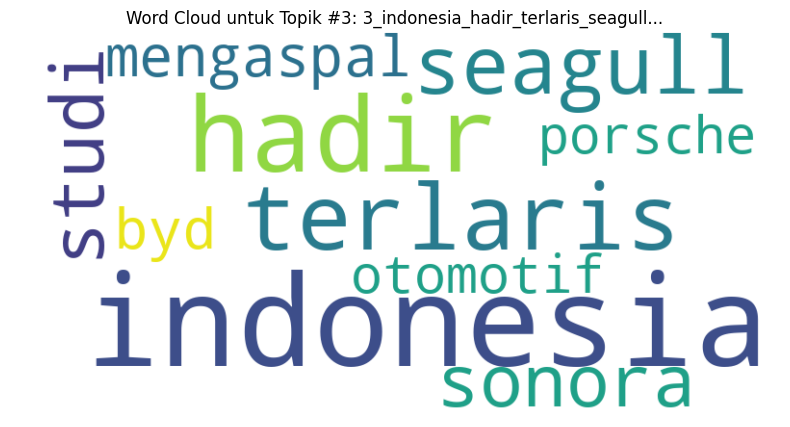

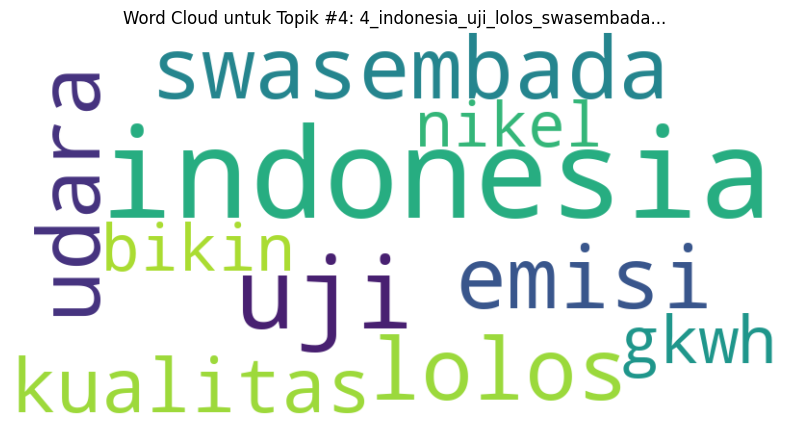

In [ ]:
# Cell 7: Visualisasi Word Cloud untuk Setiap Topik Negatif (Tidak ada perubahan, hanya konfirmasi)

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Kode ini sudah benar dan akan mengambil 'topic_model' dari Cell 6
# yang mana datanya sudah bersumber dari 'cleaned_bert'
if 'topic_model' in locals() and not topic_info[topic_info.Topic != -1].empty:
    print("\n--- Word Cloud untuk Topik-Topik Negatif ---")

    top_topics = topic_info[topic_info.Topic != -1].head(5)

    for _, row in top_topics.iterrows():
        topic_num = row.Topic
        word_scores = topic_model.get_topic(topic_num)

        if word_scores:
            wordcloud = WordCloud(
                width=800, height=400, background_color='white', colormap='viridis'
            ).generate_from_frequencies(dict(word_scores))

            plt.figure(figsize=(10, 5))
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.axis("off")
            plt.title(f"Word Cloud untuk Topik #{topic_num}: {row.Name[:40]}...")
            plt.show()
else:
    print("Silakan jalankan sel Analisis Topik (Cell 6) terlebih dahulu.")

In [ ]:
# === AUTO-GENERATED THUMBNAIL EXPORT ===
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os

# Find all existing figure axes
figures = [plt.figure(i) for i in plt.get_fignums()]
if figures:
    fig = figures[-1]  # Use last figure
else:
    # Create a summary figure from available data
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.text(0.5, 0.5, 'Project Visualization', fontsize=24, 
            ha='center', va='center', transform=ax.transAxes,
            fontweight='bold', color='#2d3436')
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('#f8f9fa')
    ax.axis('off')

thumbnail_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'thumbnail.png')
fig.savefig(thumbnail_path, dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print(f"✅ Thumbnail saved: {thumbnail_path}")
plt.show()
